<a href="https://colab.research.google.com/github/GabrielaTranslite/Sentiment_Analysis_Video_Games/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Reading the reviews file
reviews = pd.read_csv("steam_reviews_3274580.csv")
reviews.head()

,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count
0,227214755,3274580,76561198126302244,True,0,0,ok,1780643526,2026-06-05,512.93,0.50000,0
1,227173990,3274580,76561198069792288,True,0,0,I don't understand people. Of course if Ubisof...,1780595391,2026-06-04,59.97,0.50000,0
2,227077952,3274580,76561198389635009,True,0,0,Awesome game! I am looking forward to future c...,1780484019,2026-06-03,4.37,0.50000,0
3,227046650,3274580,76561198060971315,True,1,0,I know this game has been getting mixed review...,1780438119,2026-06-02,33.47,0.52381,0
4,227036499,3274580,76561198032581809,False,6,1,The game seems to just randomly give your city...,1780428223,2026-06-02,23.02,0.57529,0


In [4]:
# Checking for review_id duplicates in the dataset
reviews.duplicated(subset=['review_id']).sum()

# No duplicates found

np.int64(0)

In [11]:
# Checking the min publish dates
reviews['publish_date'].min()



'2025-11-12'

In [13]:
# Converting columns
reviews['publish_date'] = pd.to_datetime(reviews['publish_date'])
reviews['voted_up'] = reviews['voted_up'].astype(int) # Changing True/False > 1/0
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            5268 non-null   int64         
 1   appid                5268 non-null   int64         
 2   author_steamid       5268 non-null   int64         
 3   voted_up             5268 non-null   int64         
 4   votes_up             5268 non-null   int64         
 5   votes_funny          5268 non-null   int64         
 6   review_text          5246 non-null   object        
 7   timestamp_created    5268 non-null   int64         
 8   publish_date         5268 non-null   datetime64[ns]
 9   hours_on_record      5268 non-null   float64       
 10  weighted_vote_score  5268 non-null   float64       
 11  comment_count        5268 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(8), object(1)
memory usage: 494.0+ KB


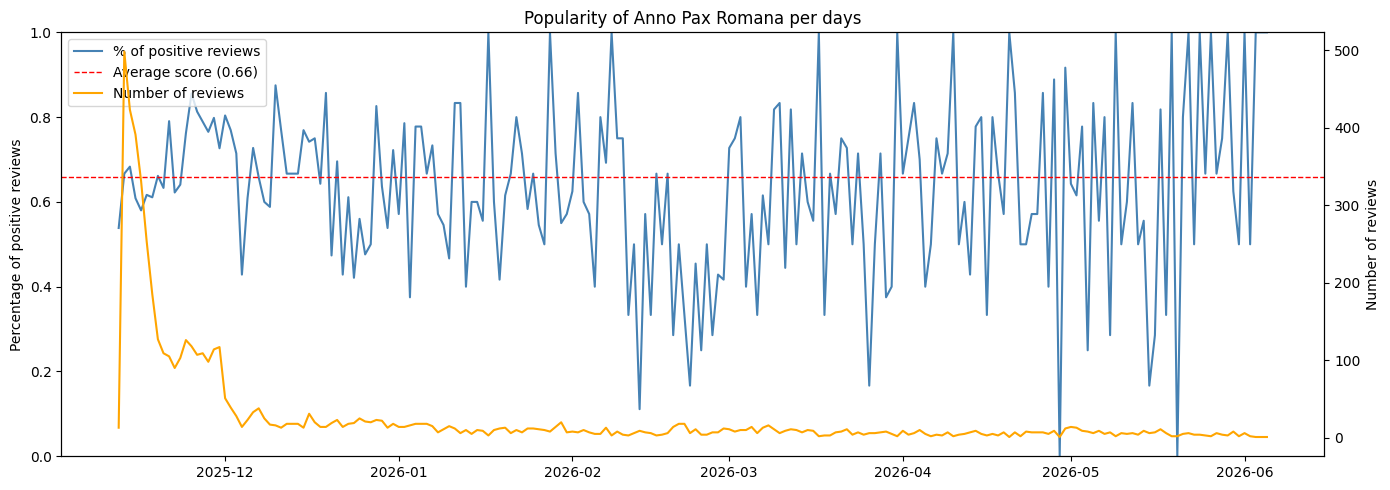

In [22]:
# Score mean and number of reviews per day
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['review_count'],
         color = 'orange',
         label = 'Number of reviews')
ax2.set_ylabel('Number of reviews')

# Global average as a horizontal reference line (on ax1, same 0-1 scale)
overall_avg = reviews['voted_up'].mean()
ax1.axhline(overall_avg, color='red', linestyle='--', linewidth=1,
            label=f'Average score ({overall_avg:.2f})')

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Popularity of Anno Pax Romana per days')
fig.tight_layout()
plt.show()

